Logs   
- [2026/04/11]    
  This is a description for exponential distribution.   
  We use the reference from (Dekking et al., 2005) - A Modern Introduction to Probability and Statistics


References
- (Weinberg and Gladen, ) 

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import numpy as np
import matplotlib.pyplot as plt

In [3]:
plt.rcParams.update(plt.rcParamsDefault)
plt.rcParams.update({
  'font.size': 16, 
  'grid.alpha': 0.25})

### The geometric distribution

In 1986, Weinberg and Gladen investigated the number of menstrual cycles it took women to become pregnant, measured from the moment they had decided to become pregnant. We model the number of cycles up to pregnancy by a random variable $X$.

Assume that the probability that a woman becomes pregnant during a particular cycle is equal to $p$, for some $p$ with $0 < p \leq 1$, independent of the previous cycles. Then cleary $\mathrm{Probl}(X = 1) = p$. Due to the independence of consecutive cycles, one finds for $k = 1, 2, \ldots, $ that 
$$
\begin{align*}
  \mathrm{Prob}(X = k) 
    &=
    \mathrm{Prob}(\text{no pregnancy in the first $k-1$ cycles, pregnancy in the $k$-th}) \\
    &= (1 - p)^{k-1} p
\end{align*}
$$

This random variable $X$ is an example of a random variable with a geometric distribution with parameter $p$

> DEFINITION   
> A discrete random variable $X$ has a _geometric distribution_ with parameter $p$, where $0 < p \leq 1$, if its probability mass function is given by
> $$
> p_X(k) = \mathrm{Prob}(X = k) = (1-p)^{k-1} p, \qquad \text{for } k = 1, 2, \ldots
> $$
> We denote this distribution by $\mathrm{Geo}(p)$

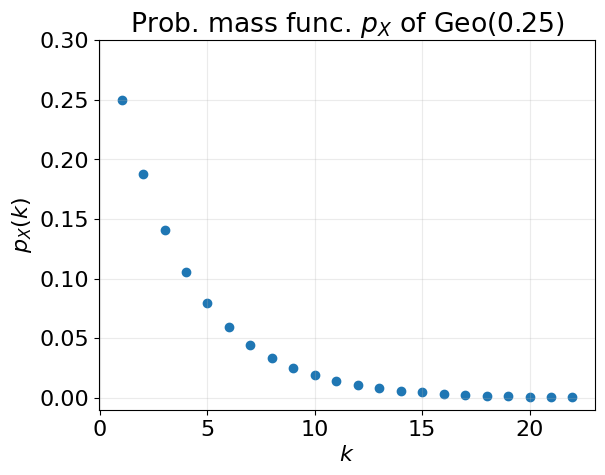

In [4]:
fig, ax = plt.subplots()

p = 0.25
k_data = np.arange(1, 23)
p_X_data = (1 - p)**(k_data-1) * p

ax.scatter(k_data, p_X_data)

ax.grid("on")
ax.set_xlabel("$k$")
ax.set_ylabel("$p_X(k)$")
ax.set_ylim([-0.01, 0.3])
ax.set_title(f"Prob. mass func. $p_X$ of Geo({p})")
plt.show(fig)

> DEFINITION   
> The _distribution function_ $F$ of a random variable $X$ is the function $F: \mathbb{R} \rightarrow [0, 1]$, defined by
> $$
> F(a) = \mathrm{Prob}(X \leq a) \qquad \text{for } -\infty < a < \infty
> $$

An example of distribution function of $\mathrm{Geo}(p)$

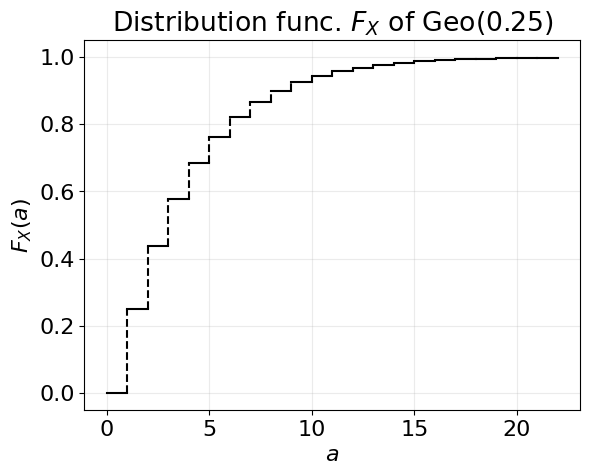

In [5]:
a_data = k_data.copy()
F_X_data = np.cumsum(p_X_data)

fig, ax = plt.subplots()

x_horizontal = np.concatenate(([0], a_data))
y_horizontal = np.concatenate(([0], F_X_data))

for idx in range(len(x_horizontal)-1):
  ax.plot([x_horizontal[idx], x_horizontal[idx+1]],
          [y_horizontal[idx], y_horizontal[idx]], color="k")


for idx in range(len(x_horizontal)-2):
  ax.plot([x_horizontal[idx+1], x_horizontal[idx+1]],
          [y_horizontal[idx], y_horizontal[idx+1]], color="k", 
          linestyle="--")

ax.grid("on")
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel("$a$")
ax.set_ylabel("$F_X(a)$")
ax.set_title(f"Distribution func. $F_X$ of Geo({p})")

plt.show(fig)

**Quick exercie 4.6**   
Let $X$ have a $\mathrm{Geo}(p)$ distribution. For $n \geq 0$, show that 
$\mathrm{Prob}(X > n) = (1 - p)^n$.

**Answer**   
There are two ways to show that $\mathrm{Prob}(X > n) = (1 - p)^n$. The easiest 
way to realize that $\mathrm{Prob}(X > n)$ is the probability that we had 
"no success in the first $n$ trials", which clearly equals $(1 - p)^n$.
A more involved way is by calculation:
$$
\begin{align*}
  \mathrm{Prob}(X > n)
    &= \mathrm{Prob}(X = n + 1) + \mathrm{Prob}(X = n + 2) + \ldots \\
    &= (1 - p)^n p + (1 - p)^{n+1}p + \ldots \\
    &= (1 - p)^n p (1 + (1-p) + (1 - p)^2 + \ldots) 
\end{align*}
$$

If we recall from calculus that
$$
\begin{align*}
  \sum_{k = 0}^\infty (1 - p)^k
    = \frac{1}{1 - (1 - p)} = \frac{1}{p}
\end{align*}
$$
the answer follows immediately.

The geometric distribution has a remarkable property, which is known as the 
_memoryless property_. For $n, k = 0, 1, 2, \ldots$ one has
$$
\mathrm{Prob}(X > n + k \mid X > k) = \mathrm{Prob}(X > n)
$$
It means that the probability of having to wait an additional $n$ trials, given 
that $k$ trials have already failed, is the same as the initial probability
of waiting $n$ trials.

We can derive this equality using the result from **Quick exercise 4.6**
$$
\begin{align*}
  \mathrm{Prob}(X > n + k \mid X > k) 
    &= \frac{\mathrm{Prob}((\infty, n + k) \cap (\infty, k))}{\mathrm{Prob}((\infty, k))}  \\
    &= \frac{\mathrm{Prob}((\infty, n+k))}{\mathrm{Prob}((\infty, k))} \\
    &= \frac{\mathrm{Prob}(X > n+k)}{\mathrm{Prob}(X > k)} \\
    &= \frac{(1 - p)^{n+k}}{(1 - p)^k} \\
    &= (1-p)^n =\mathrm{Prob}(X > n)
\end{align*}
$$


> In fact, the geometric distribution is the only discrete random variable with this property.


### The exponential distribution

Consider a continuously stirred reactor vessel where a chemical reaction take 
place.   

On one side fluid or gas flows in, mixes with whatever is already 
present in the vessel, and eventually flows out on the other side.   

One characteristic of each particular reaction setup is the so-called
residence time distribution, which tells us how long particles stay inside
the vessel before moving on.    

We consider a continuously stirred tank: the contents of the vessel are 
perfectly mixed at all times.   


Let $v$ be the effluent volumetric flow rate, i.e., the volume that leaves 
the reactor over a time interval $[0, t]$ is $vt$ (and an equal volume enters 
the vessel at the other hand).    

Let $V$ be the volume of the reactor vessel.   

Then in total a fraction $(v/V) \cdot t$ will have left the vessel during $[0, t]$, 
when $t$ is not too large.    

Let the random variable $T$ be the residence time of a particle in the vessel.   

To compute the distribution of $T$, we divide the interval $[0, t]$ in 
$n$ small intervals of equal length $t/n$.    

Assuming perfect mixing, so that the particle's position is uniformly distributed 
over the volume, the particle has probability $p = (v/V)\cdot t/n$ to have left
the vessel during any of the $n$ intervals of length $t/n$.    

If we assume that the behavior of the particle in different time intervals of 
length $t/n$ is independent, we have, if we call "leaving the vessel" a success, 
that $T$ has a geometric distribution with success probability $p$.     

It follows that the probability $\mathrm{Prob}(T > t)$ that the particle is 
still in the vessel at time $t$ is, for large $n$, well approximated by
$$
  \mathrm{Prob}(T > t) = (1 - p)^n
    = \left(1 - \frac{vt}{Vn}\right)^n
$$


But then, letting $n \rightarrow \infty$, we obtain (remember the definition
of $e$)
$$
\begin{align*}
  \mathrm{Prob}(T > t)
    &= \lim_{n \rightarrow \infty} \left(
        1 - \frac{vt}{V} \cdot \frac{1}{n}
    \right)^n \\
    &= \lim_{n \rightarrow \infty} \left(\left(
        1 - \frac{vt}{V} \cdot \frac{1}{n}
    \right)^{-{\displaystyle\tfrac{V}{vt}} \cdot n}\right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(
      \lim_{n \rightarrow \infty} \left(
        1 - \frac{vt}{V} \cdot \frac{1}{n}
    \right)^{-{\displaystyle\tfrac{V}{vt}} \cdot n}\right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(
      \lim_{n \rightarrow \infty} \left(
        1 - \frac{vt}{V} \cdot \frac{1}{n}
    \right)^{-{\displaystyle\tfrac{V}{vt}} \cdot n}\right)^{-\displaystyle\tfrac{vt}{V}} \\
\end{align*}
$$

If we have $n \rightarrow \infty$, we can have $(V/v)\cdot (n/t) \rightarrow \infty$.
Let us defined $a = (V/v) \cdot (n/t)$, the the above equation becomes
$$
\begin{align*}
  \mathrm{Prob} (T > t)
    &= \left(\lim_{a \rightarrow \infty} 
      \left(1 - \frac{1}{a}\right)^{-a}
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(\lim_{a \rightarrow \infty} 
      \left(\frac{a - 1}{a}\right)^{-a}
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(\lim_{a \rightarrow \infty} 
      \left(\frac{a}{a-1}\right)^{a}
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(\lim_{a \rightarrow \infty} 
      \left(\frac{a-1 + 1}{a-1}\right)^{a}
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(\lim_{a-1 \rightarrow \infty} 
      \left(\frac{a-1 + 1}{a-1}\right)^{a-1 + 1}
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(\lim_{k \rightarrow \infty} 
      \left(\frac{k + 1}{k}\right)^{k + 1}
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(\lim_{k \rightarrow \infty} 
      \left(1 + \frac{1}{k}\right)^{k} \lim_{k \rightarrow \infty} 
        \left(1 + \frac{1}{k}\right)
      \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= \left(e \cdot (1 + 0) \right)^{-\displaystyle\tfrac{vt}{V}} \\
    &= e^{-\displaystyle\tfrac{vt}{V}} 
\end{align*}
$$

It follows that the distribution function of $T$ equals $1 - e^{-\displaystyle\tfrac{v}{V}t}$, and differentiating we obtain the probability density function $f_T$ of T
is equal to 
$$
  f_T(t) = \frac{\mathrm{d}}{\mathrm{d}t}
    \left(1 - e^{-\displaystyle\tfrac{v}{V}t}\right)
    = \frac{v}{V} e^{-\displaystyle\tfrac{v}{V}t}
    \qquad \text{for } t \geq 0
$$
This is an example of an exponential distribution, with parameter $v/V$.

>DEFINITION    
>A continuous random variable has an _exponential distribution_ with parameter 
>$\lambda$ if its probability density function $f$ is given by $f(x) = 0$ if 
>$x < 0$ and
>$$
f(x) = \lambda e^{-\lambda x} \qquad \text{for } x \geq 0
>$$
>We denote this distribution by $\mathrm{Exp(\lambda)}$

The distribution function $F$ of an $\mathrm{Exp}(\lambda)$ distribution is given by
$$
  F(a) = 1 - e^{-\lambda a} \qquad \text{for } a \geq 0
$$

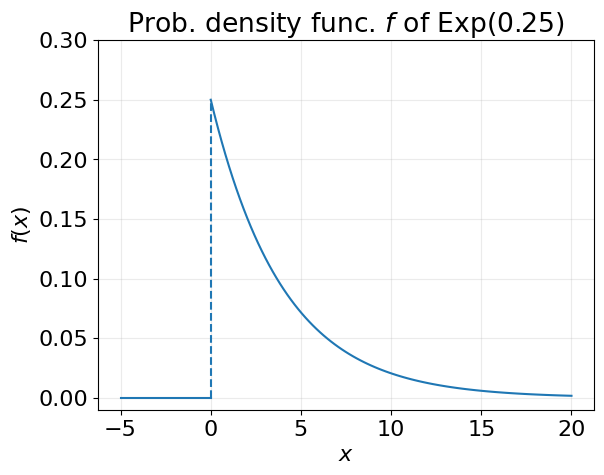

In [6]:
fig, ax = plt.subplots()

lambda_params = 0.25
x_data = np.linspace(0, 20, 100)
f_data = lambda_params * np.exp(-lambda_params*x_data)

ax.plot(x_data, f_data)
ax.plot([-5, 0], [0, 0], color="tab:blue")
ax.plot([0, 0], [0, f_data[0]], color="tab:blue", linestyle="--")

ax.grid("on")
ax.set_xlabel("$x$")
ax.set_ylabel("$f(x)$")
ax.set_ylim([-0.01, 0.3])
ax.set_title(f"Prob. density func. $f$ of Exp({lambda_params})")
plt.show(fig)

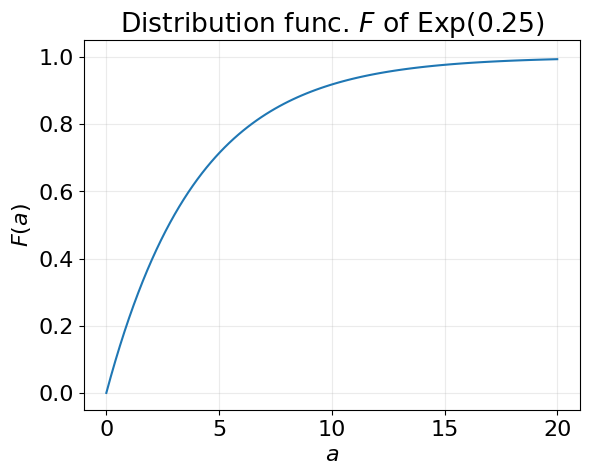

In [7]:
a_data = np.linspace(0, 20, 100)
F_data = 1. - np.exp(-lambda_params*a_data)

fig, ax = plt.subplots()

ax.plot(a_data, F_data)

ax.grid("on")
ax.set_ylim([-0.05, 1.05])
ax.set_xlabel("$a$")
ax.set_ylabel("$F(a)$")
ax.set_title(f"Distribution func. $F$ of Exp({p})")

plt.show(fig)

Since we obtain the exponential distribution directly from the geometric
distribution it should be not come as a surprise that the exponential 
distribtion _also_ satisfies the memoryless property, i.e., if $X$ has an 
exponential distribution, then for all $s, t > 0$,
$$
  \mathrm{Prob}(X > s + t \mid X > s) = \mathrm{Prob}(X > t)
$$
Actually, this follows directly from
$$
\begin{align*}
  \mathrm{Prob}(X > s+t \mid X > s)
    &= \frac{\mathrm{Prob}((\infty, s+t) \cap (\infty, s))}{
      \mathrm{Prob}((\infty, s))} \\
    &= \frac{\mathrm{Prob}((\infty, s+t))}{\mathrm{Prob}((\infty, s))} \\
    &= \frac{\mathrm{Prob}(X > s+t)}{\mathrm{Prob}(X>s)} \\
    &= \frac{1 - \mathrm{Prob}(X \leq s+t)}{1 - \mathrm{Prob}(X \leq s)} \\
    &= \frac{1 - F(s+t)}{1 - F(s)} \\
    &= \frac{1 - (1 - e^{-\lambda(s+t)})}{1 - (1 - e^{-\lambda s})} \\
    &= \frac{e^{-\lambda(s+t)}}{e^{-\lambda s}}  \\
    &= e^{-\lambda t} = \mathrm{Prob}(X > t)
\end{align*}
$$

From (https://www.probabilitycourse.com/chapter4/4_2_2_exponential.php)

Suppose you are waiting for an event to happen.    
For example, you are at a store and are waiting for the next customer.  
In each millisecond, the probability that a new customer enters the store is very small.   
You can imagine that, in each millisecond, a coin (with a very small $P(H)$) is tossed, 
and if it lands heads a new customers enters.   
If you toss a coin every millisecond, the time until a new customer arrives 
approximately follows an exponential distribution.

From the point of view of waiting time until arrival of a customer, the memoryless property means that it does not matter how long you have waited so far.   
If you have not observed a customer until time $s$, the distribution of waiting
time (from time $s$) until the next customer is the same as when 
you started at time zero.

Memoryless property proof by the probability density function ($f$) plot
and distribution function ($F$)

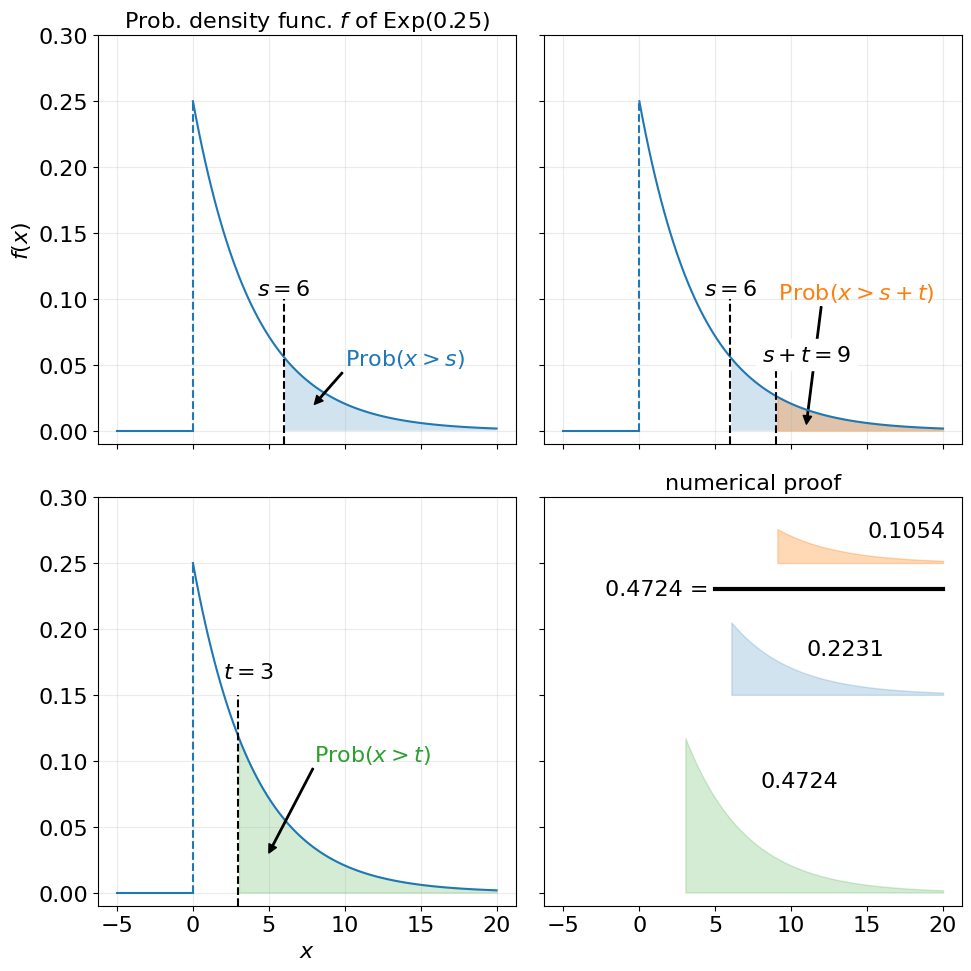

In [108]:
fig, axes = plt.subplots(ncols=2, nrows=2, sharex=True, sharey=True, figsize=(10, 10))

lambda_params = 0.25
x_data = np.linspace(0, 20, 100)
f_data = lambda_params * np.exp(-lambda_params*x_data)

t = 3
s = 6

# -- Prob(X > s)
axes[0, 0].plot(x_data, f_data)
axes[0, 0].plot([-5, 0], [0, 0], color="tab:blue")
axes[0, 0].plot([0, 0], [0, f_data[0]], color="tab:blue", linestyle="--")

idx_ge_s = x_data > s
x_ge_s = x_data[idx_ge_s]
f_ge_s = f_data[idx_ge_s]
axes[0, 0].fill_between(x_ge_s, f_ge_s, alpha=0.2)

axes[0, 0].plot([s, s], [-0.01, 0.1], linestyle="--", color="k")
axes[0, 0].text(s, 0.1, f"$s = ${s}", ha="center", va="bottom")
axes[0, 0].annotate(r"$\mathrm{{Prob}}(x > s)$", [8, 0.02], [10, 0.05], 
                 ha="left", color="tab:blue",
                 arrowprops={"facecolor": "k", "width": 1, "headwidth": 6,
                             "headlength": 6})
# -- Prob(X > s + t)
axes[0, 1].plot(x_data, f_data)
axes[0, 1].plot([-5, 0], [0, 0], color="tab:blue")
axes[0, 1].plot([0, 0], [0, f_data[0]], color="tab:blue", linestyle="--")

idx_ge_s_t = x_data > s + t
x_ge_s_t = x_data[idx_ge_s_t]
f_ge_s_t = f_data[idx_ge_s_t]
axes[0, 1].fill_between(x_ge_s, f_ge_s, alpha=0.2)
axes[0, 1].fill_between(x_ge_s_t, f_ge_s_t, color="tab:orange", alpha=0.3)

axes[0, 1].plot([s, s], [-0.01, 0.1], linestyle="--", color="k")
axes[0, 1].text(s, 0.1, f"$s = ${s}", ha="center", va="bottom")
axes[0, 1].plot([s+t, s+t], [-0.01, 0.05], linestyle="--", color="k")
axes[0, 1].text(s+t+2, 0.05, f"$s + t = ${s+t}", ha="center", va="bottom", 
                backgroundcolor="w", zorder=2)
axes[0, 1].annotate(" "*10 + r"$\mathrm{{Prob}}(x > s+t)$", [11, 0.005], [12, 0.1], 
                 ha="center", color="tab:orange",
                 arrowprops={"facecolor": "k", "width": 1, "headwidth": 6,
                             "headlength": 6}, zorder=1)

# -- Prob(X > t)
axes[1, 0].plot(x_data, f_data)
axes[1, 0].plot([-5, 0], [0, 0], color="tab:blue")
axes[1, 0].plot([0, 0], [0, f_data[0]], color="tab:blue", linestyle="--")

idx_ge_t = x_data > t 
x_ge_t = x_data[idx_ge_t]
f_ge_t = f_data[idx_ge_t]
axes[1, 0].fill_between(x_ge_t, f_ge_t, color="tab:green", alpha=0.2)

axes[1, 0].plot([t, t], [-0.01, 0.15], linestyle="--", color="k")
axes[1, 0].text(t-1, 0.16, f"$t = ${t}", ha="left", va="bottom")
axes[1, 0].annotate(r"$\mathrm{{Prob}}(x > t)$", [5, 0.03], [8, 0.1], 
                 ha="left", color="tab:green",
                 arrowprops={"facecolor": "k", "width": 1, "headwidth": 6,
                             "headlength": 6})
# -- comparison
y_shift = 0.25
axes[1, 1].fill_between(x_ge_s_t, f_ge_s_t+y_shift, y2=y_shift, color="tab:orange", alpha=0.3)
one_minus_F_data_s_t = np.exp(-lambda_params*(s+t))
axes[1, 1].text(15, 0.27, f"{one_minus_F_data_s_t:.4f}")

y_shift = 0.15
axes[1, 1].fill_between(x_ge_s, f_ge_s+y_shift, y2=y_shift, color="tab:blue", alpha=0.2)
one_minus_F_data_s = np.exp(-lambda_params*s)
axes[1, 1].text(11, 0.18, f"{one_minus_F_data_s:.4f}")

divisor_line = 0.23
axes[1, 1].plot([5, 20], [divisor_line, divisor_line], color="k", linewidth=3)
prob_cond = one_minus_F_data_s_t / one_minus_F_data_s
axes[1, 1].text(5, divisor_line, f"{prob_cond:.4f} = ", va="center", ha="right")

axes[1, 1].fill_between(x_ge_t, f_ge_t, color="tab:green", alpha=0.2)
one_minus_F_data = np.exp(-lambda_params*t)
axes[1, 1].text(8, 0.08, f"{one_minus_F_data:.4f}")

# -- format
axes[0, 0].grid("on")
axes[0, 0].set_ylabel("$f(x)$")
axes[0, 0].set_ylim([-0.01, 0.3])
axes[0, 0].set_title(f"Prob. density func. $f$ of Exp({lambda_params})", fontsize=16)

axes[0, 1].grid("on")

axes[1, 0].grid("on")
axes[1, 0].set_xlabel("$x$")

axes[1, 1].set_title(f"numerical proof", fontsize=16)

plt.tight_layout()
plt.show(fig)

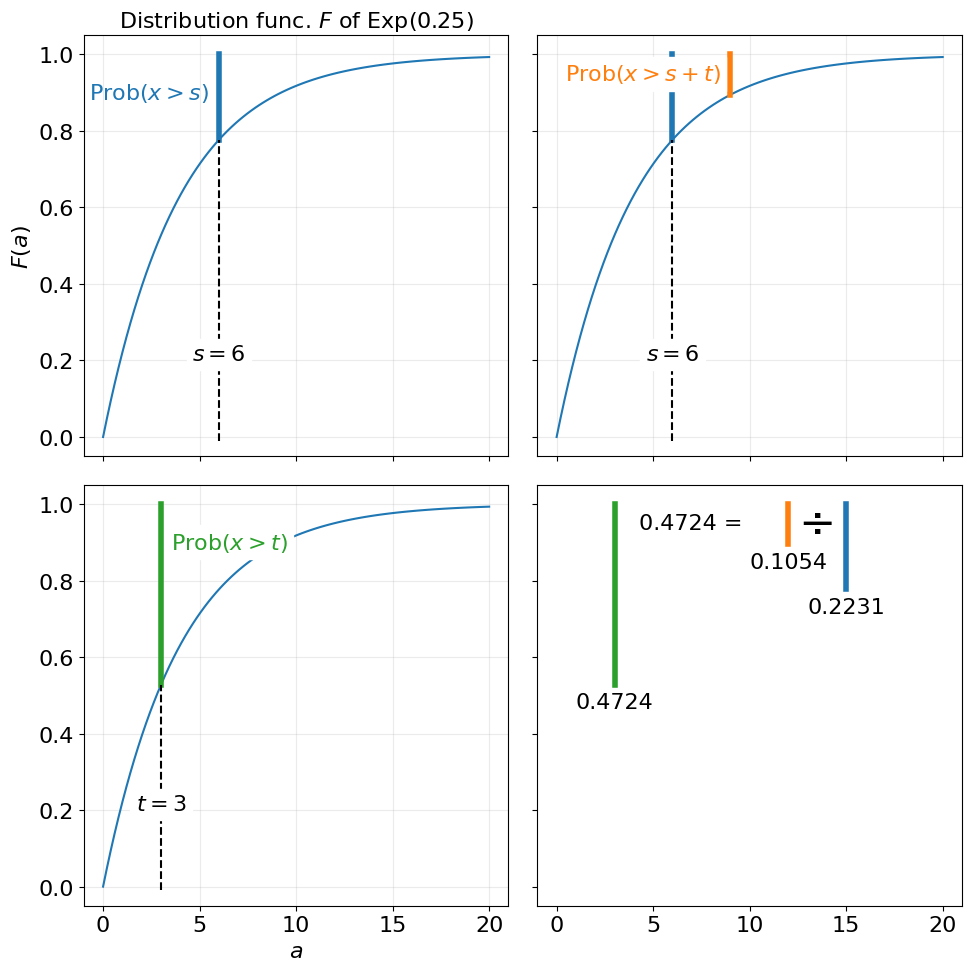

In [169]:
a_data = np.linspace(0, 20, 100)
F_data = 1. - np.exp(-lambda_params*a_data)

fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(10, 10), sharex=True, sharey=True)

s = 6
t = 3

# -- P(x > s)
axes[0, 0].plot(a_data, F_data)
F_s = 1. - np.exp(-lambda_params*s)
axes[0, 0].plot([s, s], [F_s, 1], linewidth=4, color="tab:blue")
axes[0, 0].plot([s, s], [-0.01, F_s], linestyle="--", color="k")
axes[0, 0].text(s, 0.2, f"$s = ${s}", ha="center", backgroundcolor="w")
axes[0, 0].text(s-0.5, 0.9, r"$\mathrm{Prob}(x > s)$", va="center", ha="right", 
                color="tab:blue")


# -- P(x > s + t)
axes[0, 1].plot(a_data, F_data)
F_s = 1. - np.exp(-lambda_params*s)
axes[0, 1].plot([s, s], [F_s, 1], linewidth=4, color="tab:blue")
axes[0, 1].plot([s, s], [-0.01, F_s], linestyle="--", color="k")
axes[0, 1].text(s, 0.2, f"$s = ${s}", ha="center", backgroundcolor="w")

F_s_t = 1. - np.exp(-lambda_params*(s+t))
axes[0, 1].plot([s+t, s+t], [F_s_t, 1], linewidth=4, color="tab:orange")
axes[0, 1].text(s+t-0.5, 0.95, r"$\mathrm{Prob}(x > s+t)$", va="center", ha="right", 
                color="tab:orange", backgroundcolor="w")

# -- P(x > t)
axes[1, 0].plot(a_data, F_data)
F_t = 1. - np.exp(-lambda_params*t)
axes[1, 0].plot([t, t], [F_t, 1], linewidth=4, color="tab:green")
axes[1, 0].plot([t, t], [-0.01, F_t], linestyle="--", color="k")
axes[1, 0].text(t, 0.2, f"$t = ${t}", ha="center", backgroundcolor="w")
axes[1, 0].text(t+0.5, 0.9, r"$\mathrm{Prob}(x > t)$", va="center", ha="left", 
                color="tab:green", backgroundcolor="w")

# -- comparison
x_shift = 12
axes[1, 1].plot([x_shift, x_shift], [F_s_t, 1], linewidth=4, color="tab:orange")
axes[1, 1].text(x_shift, F_s_t-0.02, f"{1 - F_s_t:.4f}", ha="center", va="top")

axes[1, 1].text(13.5, 0.95, "÷", fontsize=32, ha="center", va="center")
axes[1, 1].text(x_shift-2, 0.95, f"{(1 - F_s_t)/(1 - F_s):.4f} = ", ha="right", va="center")

x_shift = 15
axes[1, 1].plot([x_shift, x_shift], [F_s, 1], linewidth=4, color="tab:blue")
axes[1, 1].text(x_shift, F_s-0.02, f"{1 - F_s:.4f}", ha="center", va="top")

axes[1, 1].plot([t, t], [F_t, 1], linewidth=4, color="tab:green")
axes[1, 1].text(t, F_t-0.02, f"{1 - F_t:.4f}", ha="center", va="top")

# -- format
axes[0, 0].grid("on")
axes[0, 0].set_ylim([-0.05, 1.05])
axes[0, 0].set_ylabel("$F(a)$")
axes[0, 0].set_title(f"Distribution func. $F$ of Exp({p})", fontsize=16)

axes[0, 1].grid("on")
axes[1, 0].grid("on")

axes[1, 0].set_xlabel("$a$")

plt.tight_layout()
plt.show(fig)